# Ejemplos

In [2]:
import pulp

## Ejemplo 11

max $z$ = $x_1 + x_2$

s.a:

  $x_1 + 2x_2 \leq 6$

  $3x_1 + 2x_2 \leq 12$


  $x_1 \geq 0, x_2 \geq 0$

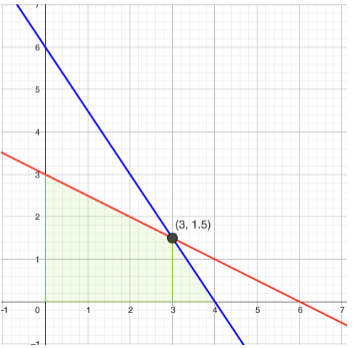

In [6]:
model = pulp.LpProblem("Maximize_Profit", pulp.LpMaximize)

x1 = pulp.LpVariable('x1', lowBound=0, cat='Continuous')
x2 = pulp.LpVariable('x2', lowBound=0, cat='Continuous')

model += x1 + x2, "Profit"

model += x1 + 2 * x2 <= 6, "Constraint1"
model += 3 * x1 + 2 * x2 <= 12, "Constraint2"
model += x1 + 2 * x2 <= 1000, "Constraint3"

model.solve()
print(f"Status: {pulp.LpStatus[model.status]}")
print(f"Result: {pulp.value(model.objective)}")
      
print(f"Cantidad de automóviles a fabricar: {pulp.value(x1)}")
print(f"Cantidad de vagonetas a fabricar: {pulp.value(x2)}")

Status: Optimal
Result: 4.5
Cantidad de automóviles a fabricar: 3.0
Cantidad de vagonetas a fabricar: 1.5


In [7]:
for constraint in model.constraints:
    constraint_sum = 0
    for var, coefficient in model.constraints[constraint].items():
        constraint_sum += var.varValue * coefficient
    print(model.constraints[constraint].name, constraint_sum)

Constraint1 6.0
Constraint2 12.0
Constraint3 6.0


Para hacer restricciones redundantes, le agregamos un parámetro a la restricción, como el ejemplo:

- Restricción redundante para la 1:
    $x_1 + 2x_2 \leq 6 + M$, $M>0$
- Restricción redundante para la 2:
    $3x_1 + 2x_2 \leq 12 + M$, $M>0$ 

# Ejemplo 13

Una compañía ha desarrollado tres nuevos productos posibles. Sin embargo, para evitar una diversificación excesiva de la línea de productos de la
compañía, la administración ha impuesto las siguientes limitaciones:

1. De los tres nuevos productos posibles, deben escogerse, como máximo, solo dos de ellos.
2. Se dispone de dos plantas que pueden fabricar los productos elegidos. Por razones administrativas, sólo una de las dos plantas debe
asignarse para la producción de los nuevos productos.

El costo unitario de producción de cada producto sería el mismo en las dos plantas. Sin embargo, por diferencias en las instalaciones, el número de
horas de producción por unidad de cada producto puede diferir entre ellas. La tabla muestra información sobre ganancias, ventas, costos, tiempo
de producción y horas disponibles por semana para cada una de las plantas. El objetivo es seleccionar los productos, la planta y las tasas de producción de los bienes elegidos de manera que se maximice la ganancia total.

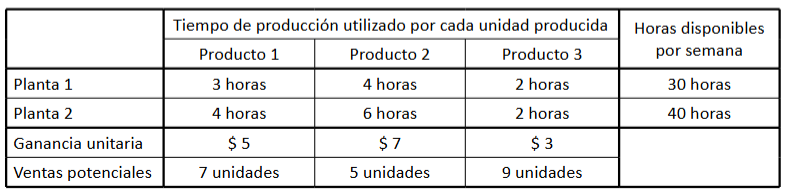

### Variables de decisión

$ I = \{ 1, 2, 3 \}$

$ J = \{1, 2 \}$

$ M = \{7, 5, 9 \}$ 

$x_i: \text{Numero de unidades producidas del producto } i$

$
y_i = \begin{cases}
1 & \text{si se produce el producto } i \\
0 & \text{en caso contrario}
\end{cases}
$

$
z = \begin{cases}
1 & \text{si se usa la planta 1}\\
0 & \text{en caso contrario}
\end{cases}
$

### Función objetivo

$\text{max } f = 5x_1 + 7x_2 + 3x_3$

### S.a

Selección de productos:

$\quad \sum_{i=1}^3 y_{i} \leq 2$

$\quad x_i \leq M_i y_i$

Planta 1:

$\quad 3x_1 + 4x_2 + 2x_3 \leq 30 + K (1 - z)$

Planta 2:

$\quad 4x_1 + 6x_2 + 2x_3 \leq 40 + K z$

Naturaleza:

$\quad x_i \in \mathbb{Z^+} \cup \{ 0 \}$

$\quad y_i, z \in \{ 0, 1 \}$

## Ejemplo 16
Una empresa de juguetes está considerando tres nuevos modelos de juguete para su posible venta en la próxima Navidad. La preparación de instalaciones para la fabricación de estos modelos costaría 25000, 35000 y 30000 dólares, respectivamente. La ganancia unitaria sería de 10, 15 y 13 dólares respectivamente. La empresa dispone de tres plantas de producción para la elaboración de estos modelos, pero para evitar gastos sólo en una de ellas
se producirían los juguetes, dependiendo de la elección de la maximización de las ganancias. El número de horas que se precisa para producir cada juguete en cada planta se presenta en la tabla. Las plantas disponen al día de 500, 600 y 630 horas de producción respectivamente. La gerencia ha decidido desarrollar al menos uno de los tres juguetes. Establecer el modelo de PE para maximizar el beneficio total